In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import SimpleImputer

In [9]:
df = pd.read_csv('Data set/retail_store_sales.csv')

df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [10]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [ ]:
df = df.drop_duplicates()

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df['Discount Applied'] = df['Discount Applied'].apply(lambda x: True if str(x).lower() == 'true' else False)

numeric_cols = df.select_dtypes(include=[np.number]).columnsط
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df['Discount Applied'] = df['Discount Applied'].fillna(False)
df = df[df['Transaction Date'] >= '2020-01-01']
df = df[df['Discount Applied'].isin([True, False])]

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [14]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11362 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(6)
memory usage: 994.8+ KB


,Price Per Unit,Quantity,Total Spent,Transaction Date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.365912,5.536380,129.652577,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,55.000000,2022-09-30 00:00:00
50%,23.365912,5.536380,112.500000,2023-07-13 00:00:00
75%,32.000000,8.000000,184.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.480118,2.788398,92.446987,NaN


In [15]:
df = df[df['Price Per Unit'] >= 0]
df = df[df['Quantity'] >= 1]
df = df[df['Quantity'] <= 10]
df = df[df['Transaction Date'] <= pd.to_datetime('today')]
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [16]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11362 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(3), object(6)
memory usage: 994.8+ KB


,Price Per Unit,Quantity,Total Spent,Transaction Date
count,12575.000000,12575.000000,12575.000000,12575
mean,23.365912,5.536380,129.652577,2023-07-12 20:23:41.105368064
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,55.000000,2022-09-30 00:00:00
50%,23.365912,5.536380,112.500000,2023-07-13 00:00:00
75%,32.000000,8.000000,184.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.480118,2.788398,92.446987,NaN


In [17]:
top_selling_products = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

revenue_by_store = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

df['Date'] = pd.to_datetime(df['Transaction Date'])
sales_over_time = df.groupby(df['Date'].dt.date)['Total Spent'].sum()

top_selling_products, revenue_by_store, sales_over_time.head()

(Item
 Item_2_BEV      676.0
 Item_16_MILK    627.0
 Item_25_FUR     616.0
 Item_19_MILK    589.0
 Item_5_FUR      581.0
 Item_13_FOOD    581.0
 Item_1_MILK     578.0
 Item_11_MILK    574.0
 Item_11_FUR     573.0
 Item_14_FOOD    566.0
 Name: Quantity, dtype: float64,
 Location
 Online      828481.637040
 In-store    801899.519505
 Name: Total Spent, dtype: float64,
 Date
 2022-01-01    1642.500000
 2022-01-02    1135.500000
 2022-01-03     823.000000
 2022-01-04    1117.500000
 2022-01-05    2357.152577
 Name: Total Spent, dtype: float64)

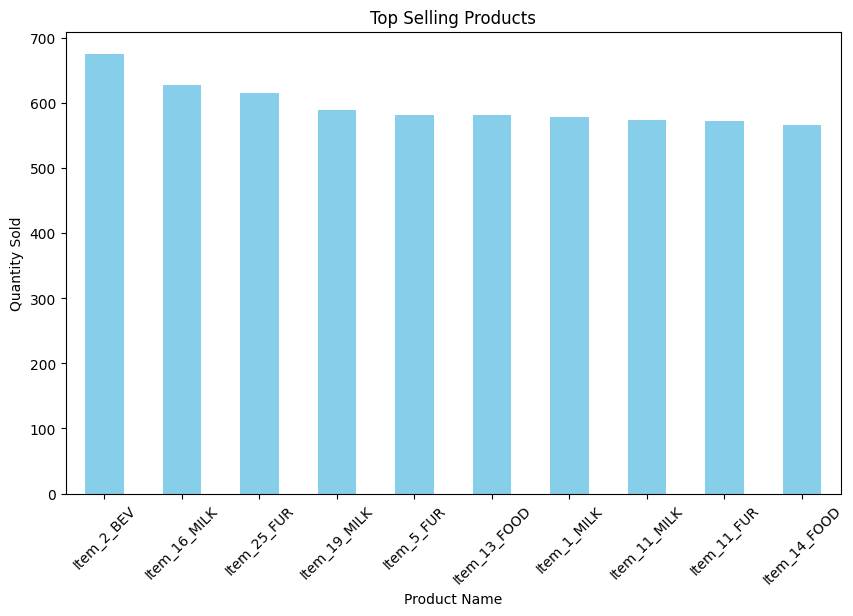

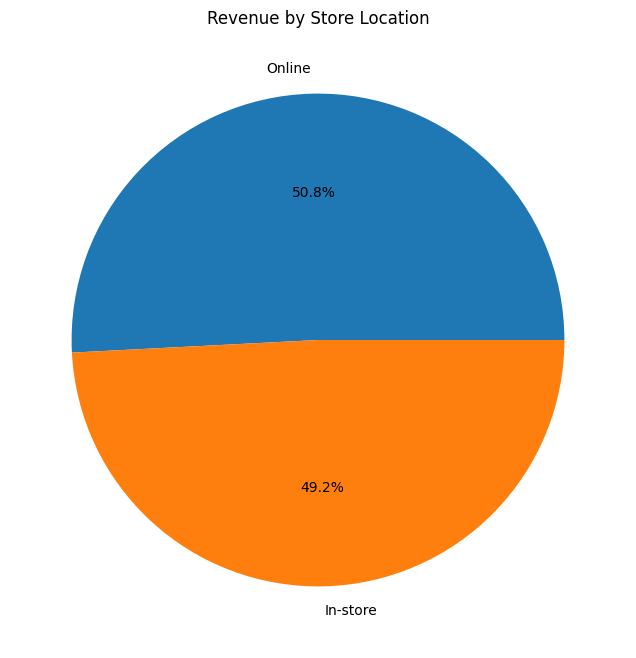

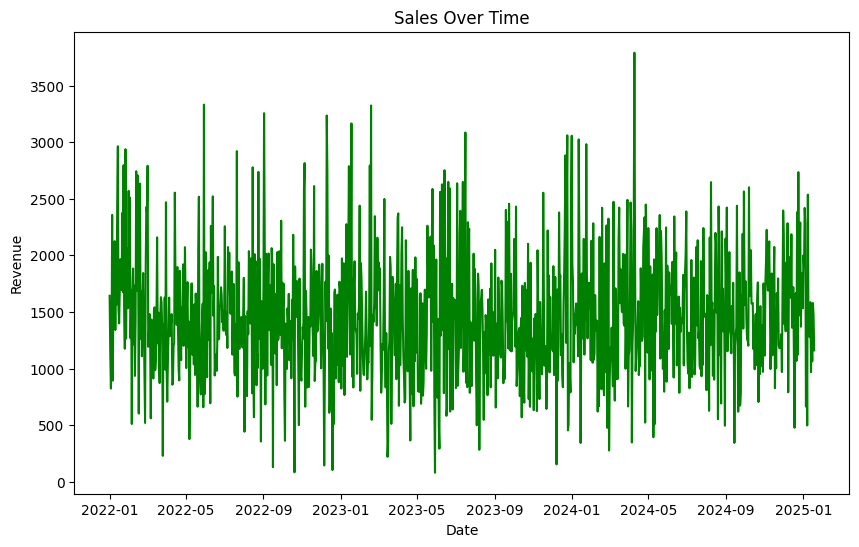

In [18]:
plt.figure(figsize=(10,6))
top_selling_products.plot(kind='bar', color='skyblue')
plt.title('Top Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,8))
revenue_by_store.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue by Store Location')
plt.ylabel('')
plt.show()

plt.figure(figsize=(10,6))
sales_over_time.plot(kind='line', color='green')
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

In [19]:
top_selling_products_summary = top_selling_products

top_stores_by_revenue = revenue_by_store.head(5)

sales_trends_summary = sales_over_time.tail(10)

print("Top Selling Products:")
print(top_selling_products_summary)
print("\nTop 5 Stores by Revenue:")
print(top_stores_by_revenue)
print("\nLatest Sales Trends (Last 10 Days):")
print(sales_trends_summary)

Top Selling Products:
Item
Item_2_BEV      676.0
Item_16_MILK    627.0
Item_25_FUR     616.0
Item_19_MILK    589.0
Item_5_FUR      581.0
Item_13_FOOD    581.0
Item_1_MILK     578.0
Item_11_MILK    574.0
Item_11_FUR     573.0
Item_14_FOOD    566.0
Name: Quantity, dtype: float64

Top 5 Stores by Revenue:
Location
Online      828481.637040
In-store    801899.519505
Name: Total Spent, dtype: float64

Latest Sales Trends (Last 10 Days):
Date
2025-01-09    1354.652577
2025-01-10    1396.152577
2025-01-11    1277.000000
2025-01-12    1586.000000
2025-01-13     968.152577
2025-01-14    1304.000000
2025-01-15    1063.652577
2025-01-16    1579.152577
2025-01-17    1476.652577
2025-01-18    1160.652577
Name: Total Spent, dtype: float64


In [20]:
df.to_csv('cleaned_data.csv', index=False)

In [21]:
with open('analysis_report.txt', 'w') as f:
    f.write("Top Selling Products:\n")
    f.write(str(top_selling_products_summary))
    f.write("\n\nTop 5 Stores by Revenue:\n")
    f.write(str(top_stores_by_revenue))
    f.write("\n\nLatest Sales Trends (Last 10 Days):\n")
    f.write(str(sales_trends_summary))